# **Project Title**

## **Heart Disease Risk Prediction Using Machine Learning**

# **Problem Statement**

- Cardiovascular diseases (CVDs) are one of the leading causes of death worldwide. Early prediction of heart disease risk helps doctors provide timely treatment and reduce mortality. However, manually analyzing patient health records is time-consuming and may overlook hidden patterns.

- The challenge is to develop a Machine Learning model that predicts whether a patient is likely to develop coronary heart disease (CHD) within the next 10 years using demographic, lifestyle, and clinical health factors.

# **1.Understand the Problem Statement**

- This project uses the Framingham Heart Study dataset to build a predictive Machine Learning model.

- The solution involves the following steps:

   - Data Collection
   - Data Inspection
   - Data Preprocessing
   - Exploratory Data Analysis (EDA)
   - Feature Engineering
   - Train-Test Split
   - Machine Learning Model Building
   - Model Evaluation
   - Prediction of Heart Disease Risk

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from feature_engine.outliers import Winsorizer
from sklearn.model_selection import train_test_split

# Linear Regression
from sklearn.linear_model import LinearRegression
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier
# Support Vector Machine
from sklearn.svm import SVC
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import cross_val_score


## **2.Data Collection**


### Load Dataset

In [3]:
df=pd.read_csv(r"D:\Datasets\framingham.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


## **Data Inspection**

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [6]:
df.shape

(4238, 16)

In [7]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [9]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [10]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [11]:
df["TenYearCHD"].value_counts()  # Traget Variable

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

## **Data Preprocessing**

In [12]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

**Fill null values (by using mode and median)**

In [13]:
df["education"] = df["education"].fillna(df["education"].median())

In [14]:
df["cigsPerDay"] = df["cigsPerDay"].fillna(df["cigsPerDay"].median())

In [15]:
df["BPMeds"] = df["BPMeds"].fillna(df["BPMeds"].mode()[0])

In [16]:
df["totChol"] = df["totChol"].fillna(df["totChol"].median())

In [17]:
df["BMI"] = df["BMI"].fillna(df["BMI"].median())

In [18]:
df["heartRate"] = df["heartRate"].fillna(df["heartRate"].median())

In [19]:
df["glucose"] = df["glucose"].fillna(df["glucose"].median())

In [20]:
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates()

In [23]:
df.nunique()

male                  2
age                  39
education             4
currentSmoker         2
cigsPerDay           33
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
totChol             248
sysBP               234
diaBP               146
BMI                1363
heartRate            73
glucose             143
TenYearCHD            2
dtype: int64

In [24]:
df = df.astype({
    "male":"int",
    "currentSmoker":"int",
    "diabetes":"int",
    "TenYearCHD":"int"
})

In [25]:
categorical = df.select_dtypes(include=['object','category']).columns

numerical = df.select_dtypes(include=['int64','float64']).columns

In [26]:
categorical

Index([], dtype='str')

In [27]:
numerical

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='str')

## **3.Exploratory Data Analysis**

### 1. Univariate Analysis

- Univariate Analysis studies one variable at a time.

##### A. Distribution of Age

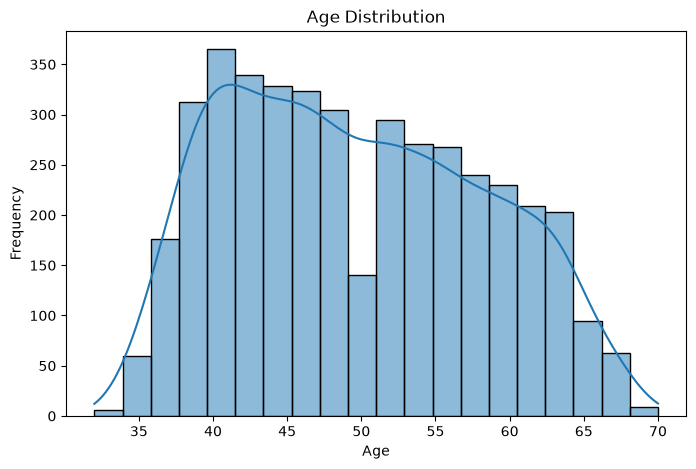

In [28]:

plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##### B. BMI Distribution

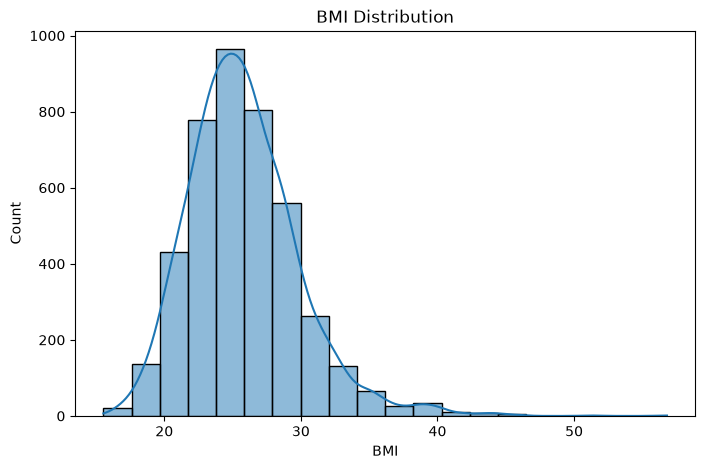

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

##### C. Target Variable Distribution

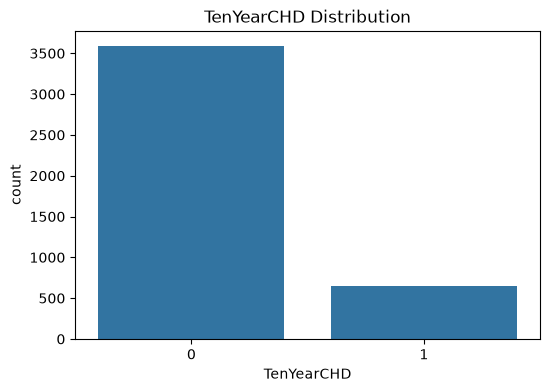

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x="TenYearCHD", data=df)
plt.title("TenYearCHD Distribution")
plt.show()

### 2. Bivariate Analysis

- Bivariate Analysis examines the relationship between two variables.

##### A. Age vs Heart Disease

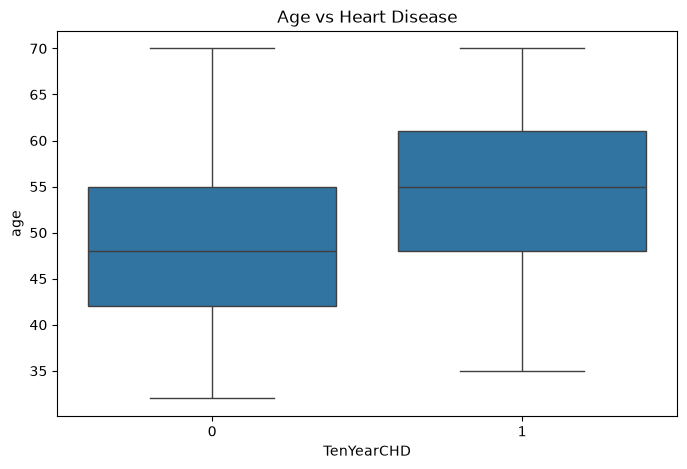

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x="TenYearCHD", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

##### B Smoking vs Heart Disease

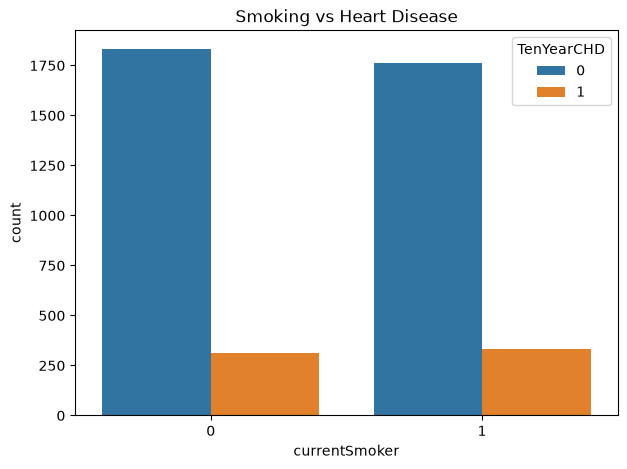

In [32]:
plt.figure(figsize=(7,5))
sns.countplot(x="currentSmoker", hue="TenYearCHD", data=df)
plt.title("Smoking vs Heart Disease")
plt.show()

##### C. Diabetes vs Heart Disease

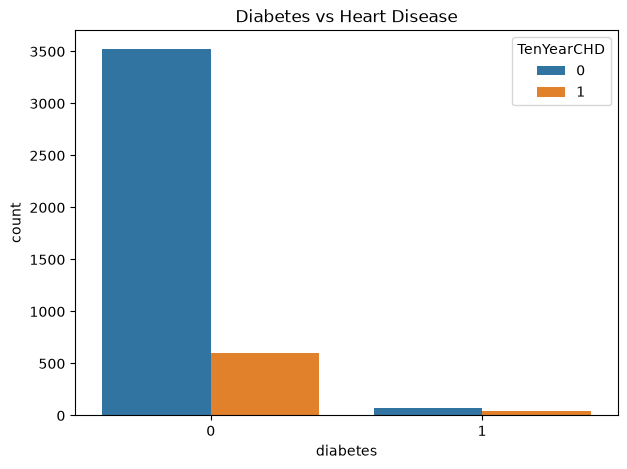

In [33]:
plt.figure(figsize=(7,5))
sns.countplot(x="diabetes", hue="TenYearCHD", data=df)
plt.title("Diabetes vs Heart Disease")
plt.show()

### 3. Correlation Analysis

- Correlation measures the strength and direction of relationships between numerical variables.

##### **Correlation Matrix**

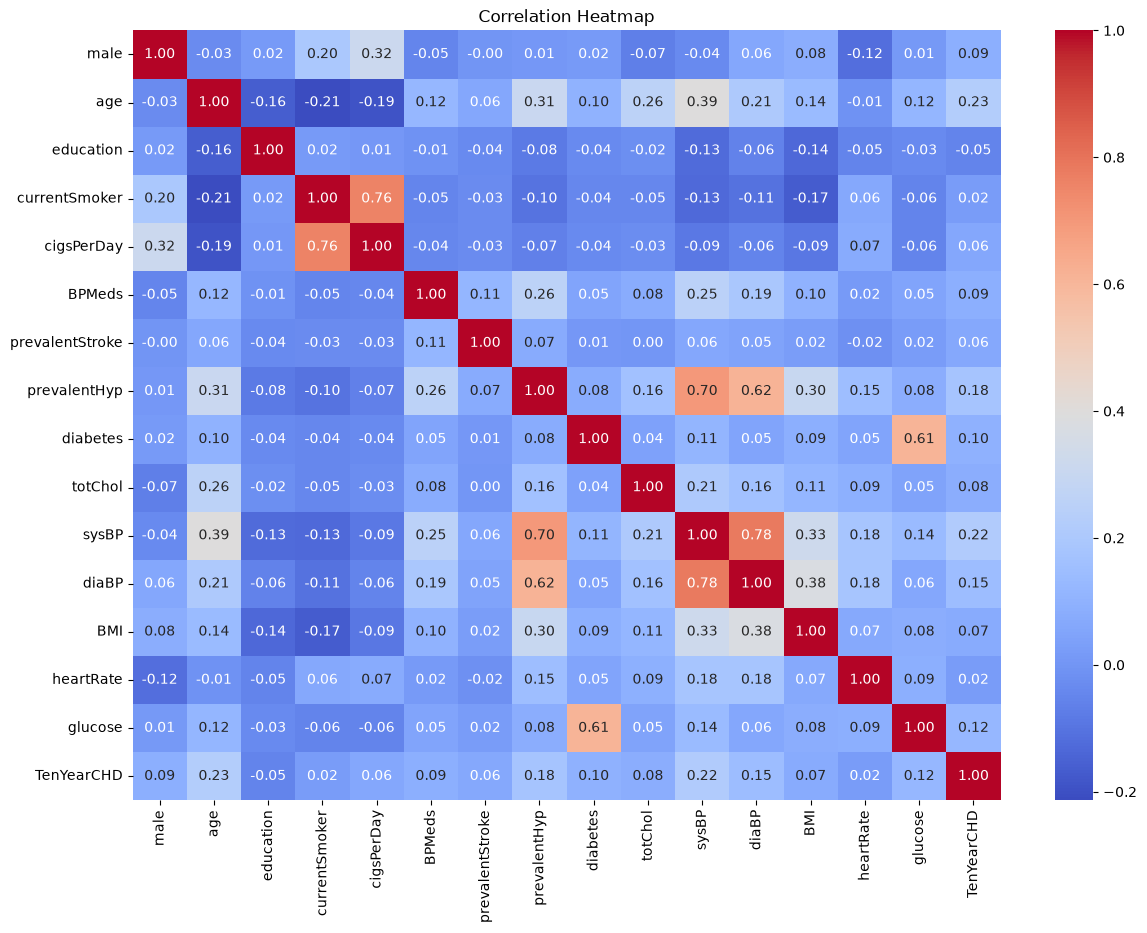

In [34]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 4. Outlier Detection

- Outliers are unusually high or low values that differ from most observations.

##### A. BMI Outliers

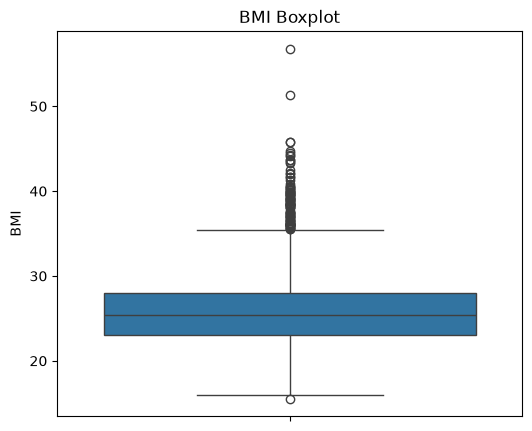

In [35]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["BMI"])
plt.title("BMI Boxplot")
plt.show()

In [36]:
!pip install feature_engine

Defaulting to user installation because normal site-packages is not writeable


In [37]:
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['BMI'])
df_win = win.fit_transform(df[['BMI']])
df_win

,BMI
0,26.97
1,28.73
2,25.34
3,28.58
4,23.10
...,...
4233,25.97
4234,19.71
4235,22.00
4236,19.16


In [38]:
print(win.left_tail_caps_,win.right_tail_caps_)

{'BMI': 15.643749999999994} {'BMI': 35.47375000000001}


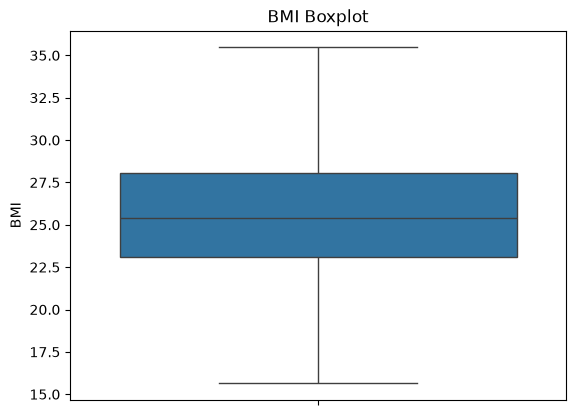

In [39]:
sns.boxplot(df_win['BMI'])
plt.title("BMI Boxplot")
plt.show()

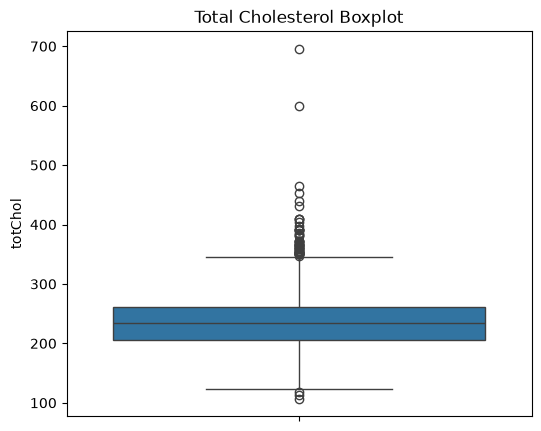

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["totChol"])
plt.title("Total Cholesterol Boxplot")
plt.show()

In [41]:
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['totChol'])
df_win = win.fit_transform(df[['totChol']])
df_win

,totChol
0,195.0
1,250.0
2,245.0
3,225.0
4,285.0
...,...
4233,313.0
4234,207.0
4235,248.0
4236,210.0


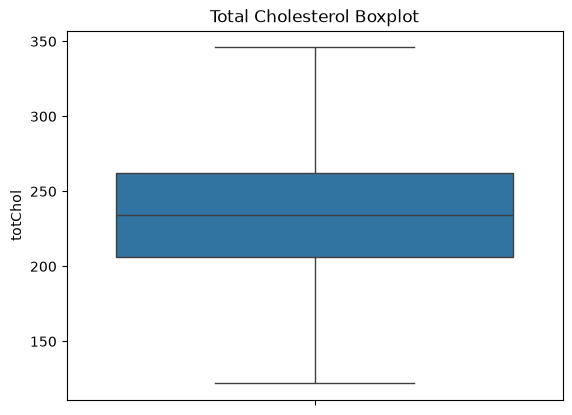

In [42]:
sns.boxplot(df_win['totChol'])
plt.title("Total Cholesterol Boxplot")
plt.show()

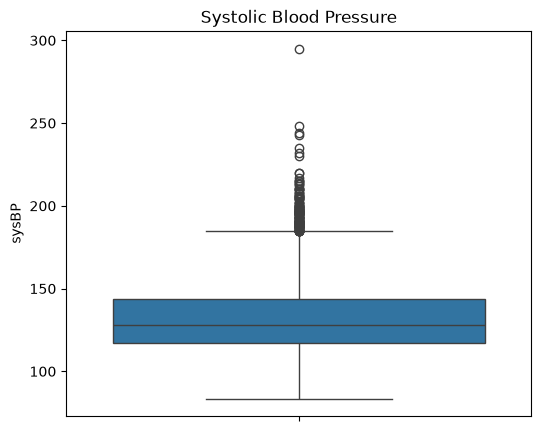

In [43]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["sysBP"])
plt.title("Systolic Blood Pressure")
plt.show()

In [44]:
win=Winsorizer(capping_method='iqr',tail='both',fold=1.5,variables=['sysBP'])
df_win = win.fit_transform(df[['sysBP']])
df_win

,sysBP
0,106.0
1,121.0
2,127.5
3,150.0
4,130.0
...,...
4233,179.0
4234,126.5
4235,131.0
4236,126.5


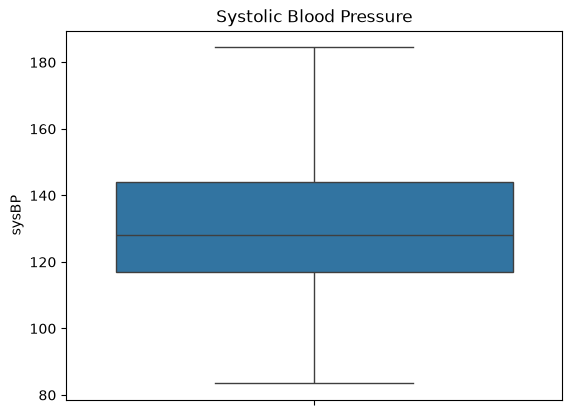

In [45]:
sns.boxplot(df_win['sysBP'])
plt.title("Systolic Blood Pressure")
plt.show()

### 5. Feature Relationship Analysis

- This explores relationships among multiple variables.

##### Pair Plot

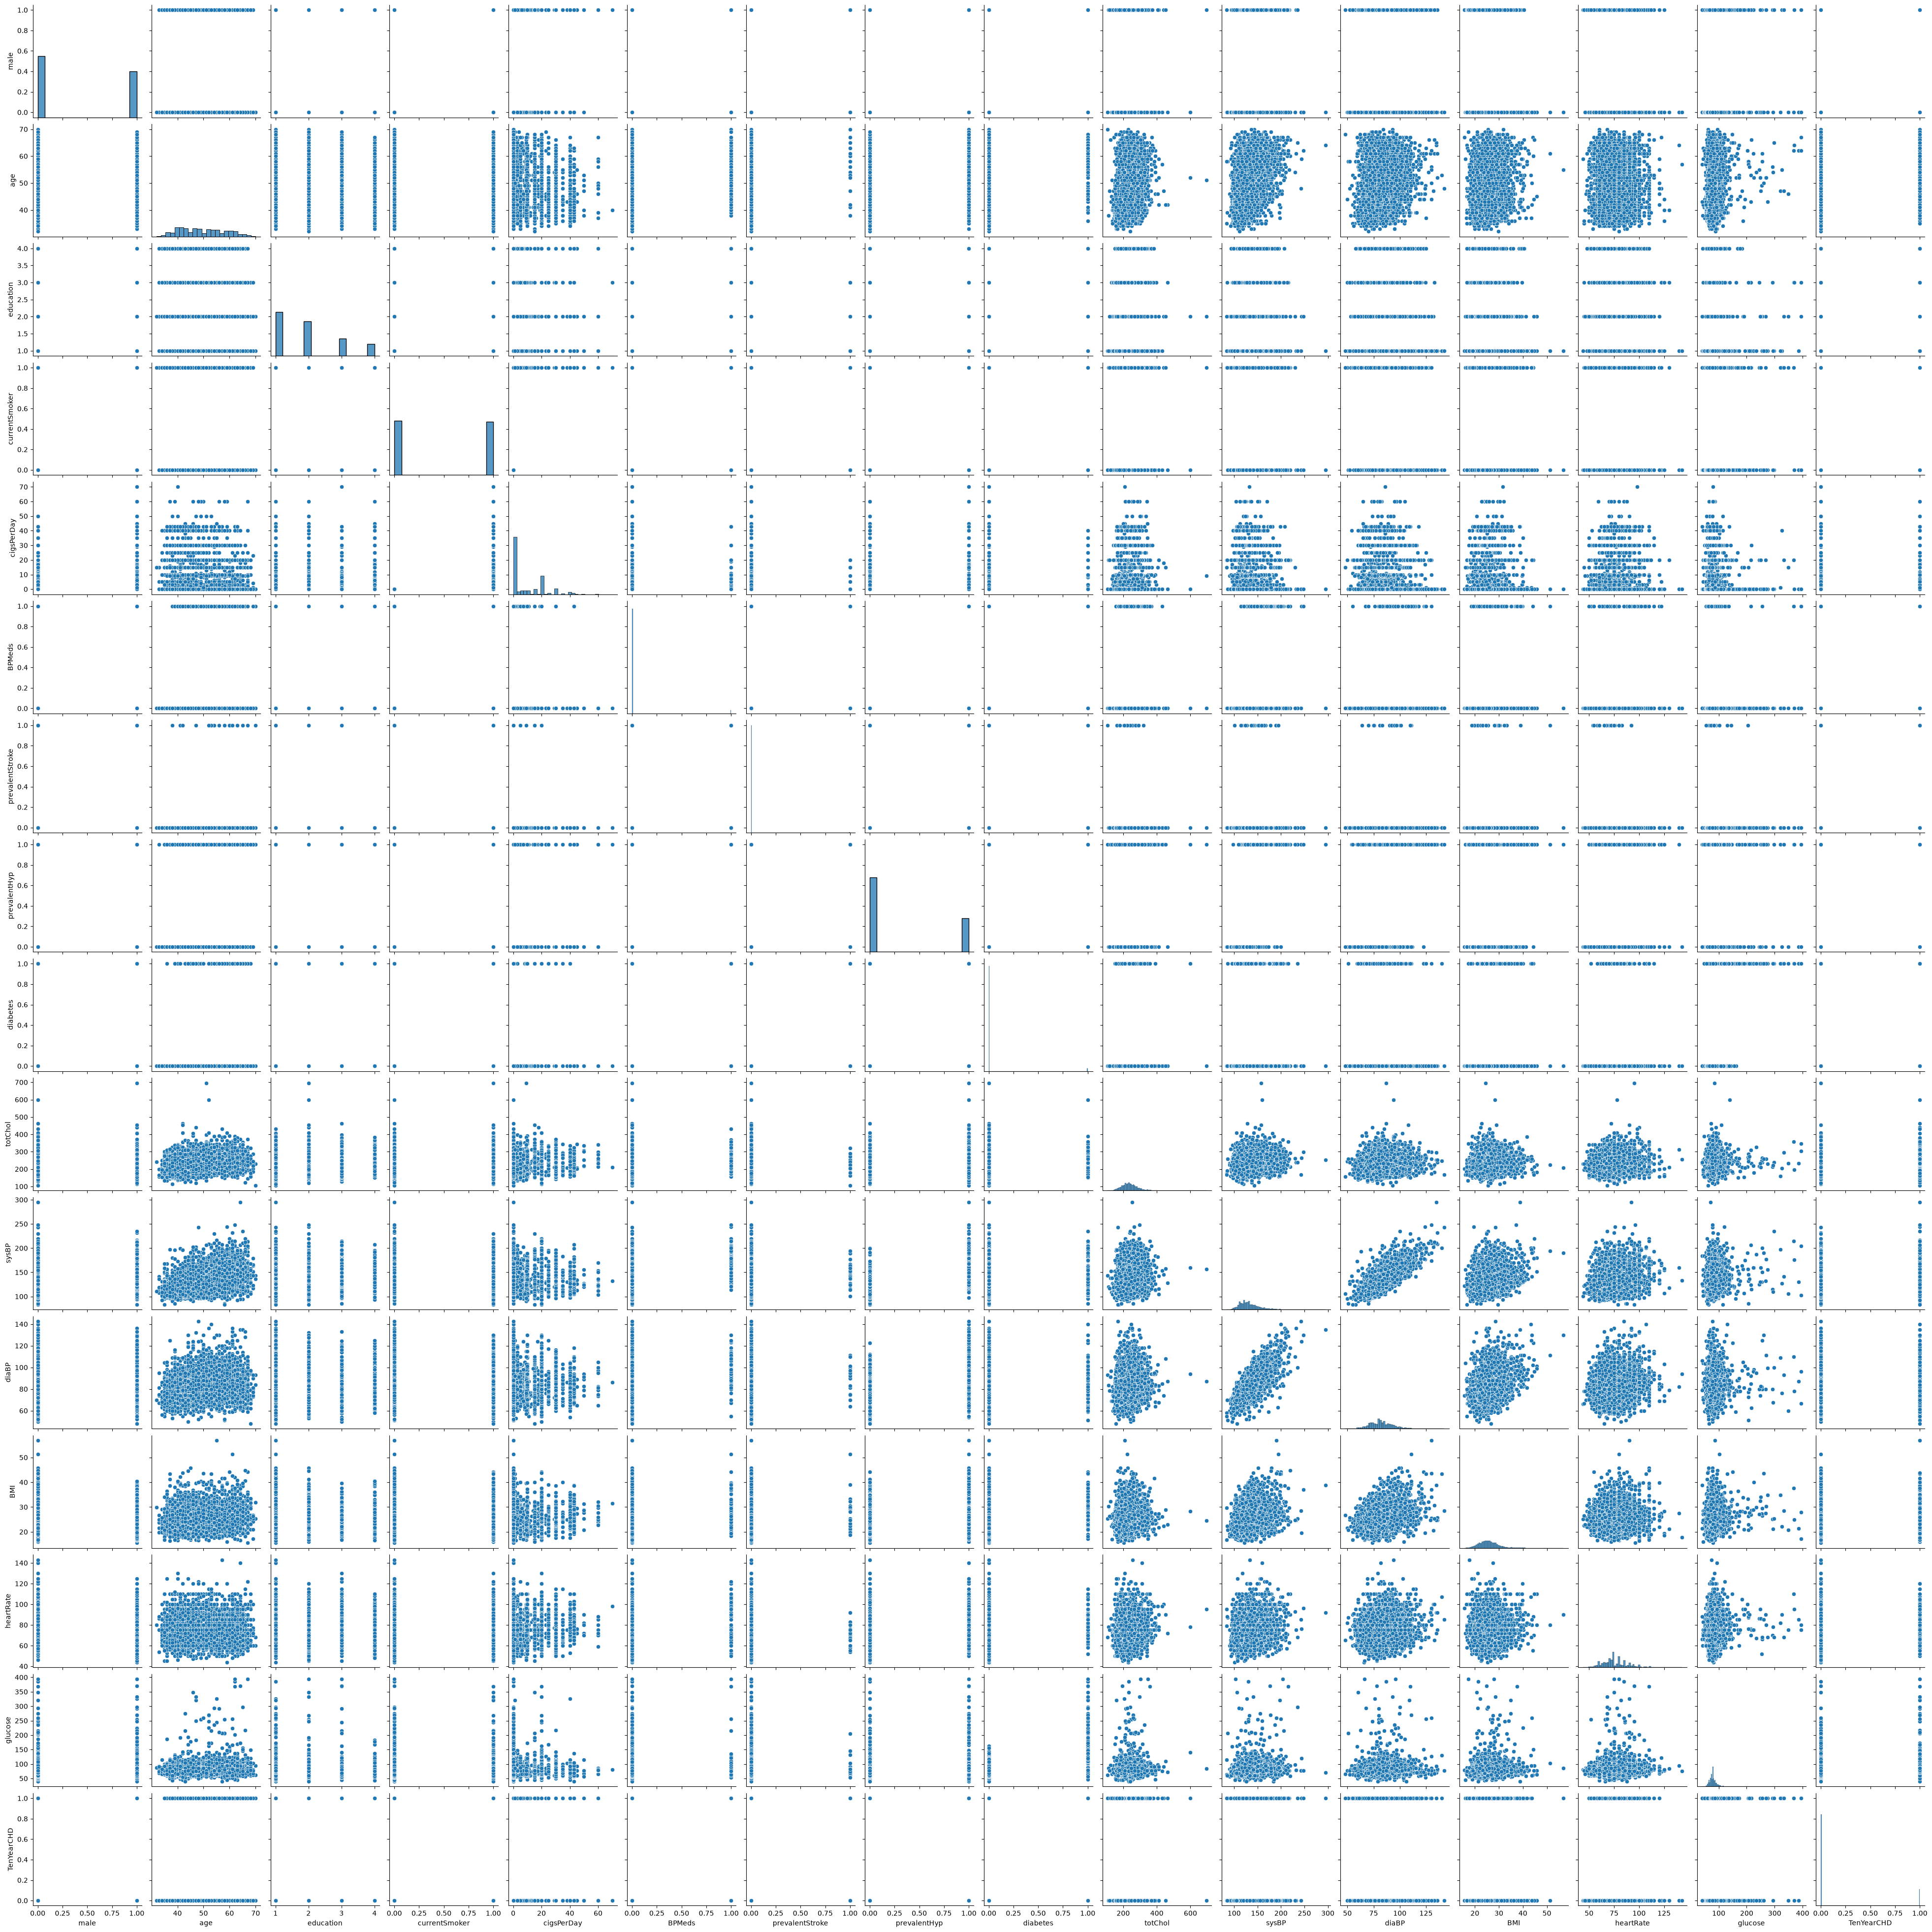

In [46]:
sns.pairplot(df)
plt.show()

##### Scatter Plot: Age vs Cholesterol

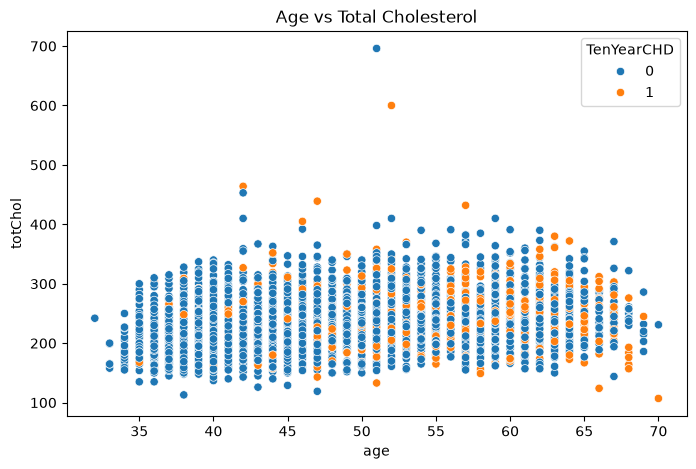

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="age",
    y="totChol",
    hue="TenYearCHD",
    data=df
)
plt.title("Age vs Total Cholesterol")
plt.show()

## **4.Feature Selection**

In [48]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

In [49]:
X.shape

(4238, 15)

In [50]:
y.shape

(4238,)

In [51]:
X.size

63570

In [52]:
y.size

4238

### **Train-Test Split**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
X_train.shape,X_test.shape

((3390, 15), (848, 15))

### Feature Scalling

- Scaling ensures that all numerical features are on a similar scale, preventing features with larger values (e.g., sysBP, glucose) from dominating the model.

- the scaler is fitted only on the training data and then applied to the test data.

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
# Create the Scaler Object

scaler = StandardScaler()

In [57]:
# Fit and Transform the Training Data
X_train_scaled = scaler.fit_transform(X_train)
# Transform the Test Data
X_test_scaled = scaler.transform(X_test)
# Check the Scaled Data
print(X_train_scaled[:5])

[[ 1.16861732 -1.11033368  2.02618479  1.00177148  1.76438134 -0.17344175
  -0.07895127 -0.67541511 -0.16037022 -0.7158791  -0.06284123 -0.16592129
  -0.51056491 -0.83777307  0.23717778]
 [-0.85571212  0.87196279  0.0291601  -0.99823165 -0.7554909  -0.17344175
  -0.07895127  1.48057097 -0.16037022  0.29585283  0.90928719  0.79521416
   1.57624478 -0.08342127  0.54626826]
 [-0.85571212 -0.29409396 -0.96935225 -0.99823165 -0.7554909  -0.17344175
  -0.07895127 -0.67541511 -0.16037022 -0.1538058  -0.42456343 -1.00169125
   0.27838064  0.58711366 -0.38100319]
 [ 1.16861732 -0.99372801  0.0291601   1.00177148  1.76438134 -0.17344175
  -0.07895127 -0.67541511 -0.16037022 -0.19877167 -0.87671618 -0.0405558
  -0.0406066  -0.75395621 -0.51347054]
 [-0.85571212  1.68820251 -0.96935225 -0.99823165 -0.7554909  -0.17344175
  -0.07895127  1.48057097 -0.16037022 -0.10883994  0.77364136  0.08480969
  -1.30194549 -0.67013934  0.63457983]]


In [58]:
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

# **5.Modelling**

### i)**Linear Regression**

- ❌ Linear Regression is designed for predicting continuous values (e.g., house prices, sales, temperature).

### **ii) Logistic Regression**



In [59]:
log_model = LogisticRegression()
log_model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [60]:
log_pred = log_model.predict(X_test)

**Model Evaluation**

In [61]:
accuracy = accuracy_score(y_test, log_pred)
precision = precision_score(y_test, log_pred)
recall = recall_score(y_test, log_pred)
f1 = f1_score(y_test, log_pred)

print("\n========== LOGISTIC REGRESSION ==========\n")

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")


========== LOGISTIC REGRESSION ==========

Accuracy      : 0.8550
Precision     : 0.5556
Recall        : 0.0403
F1 Score      : 0.0752


**check overfit/underfit**

In [62]:
log_train_pred = log_model.predict(X_train)

train_accuracy = accuracy_score(y_train, log_train_pred)
test_accuracy = accuracy_score(y_test, log_pred)

print("\nTraining Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)


Training Accuracy : 0.8489675516224189
Testing Accuracy  : 0.8549528301886793


In [63]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### **iii) Decision Tree Classifier**

- It is a supervised machine learning classification algorithm.
- It works by creating decision rules from features.
- It does not require feature scaling (unlike Logistic Regression).
- It can capture non-linear relationships.

In [64]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
dt_model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [65]:
dt_pred = dt_model.predict(X_test)

- "Decision Tree Classifier was evaluated using Accuracy, Precision, Recall, F1-score because the problem is a classification task."

In [66]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("\n========== DECISION TREE CLASSIFIER ==========\n")


print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)


========== DECISION TREE CLASSIFIER ==========

Accuracy : 0.7712264150943396
Precision: 0.2426470588235294
Recall   : 0.2661290322580645
F1 Score : 0.25384615384615383


**Check overfit / underfit**

In [67]:
# Training prediction
dt_train_pred = dt_model.predict(X_train)

train_accuracy = accuracy_score(y_train, dt_train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, dt_pred)


print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 0.7712264150943396


**this is Overfitting**
- "The initial Decision Tree classifier showed overfitting with 100% training accuracy and 77% testing accuracy. Hyperparameter tuning using max_depth, min_samples_split, and min_samples_leaf was applied to improve generalization."

In [68]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [69]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    ccp_alpha=0.01,
    random_state=42
)

In [70]:
dt_model.fit(X_train, y_train)
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

print("Training Accuracy:",
      accuracy_score(y_train, dt_train_pred))

print("Testing Accuracy:",
      accuracy_score(y_test, dt_test_pred))

Training Accuracy: 0.8466076696165191
Testing Accuracy: 0.8537735849056604


### **iv) Random Forest Classifier**
- Random Forest is an ensemble learning algorithm.
- It combines multiple Decision Trees and gives the final prediction by voting.
- It reduces overfitting compared to a single Decision Tree.
- It works well for medical datasets like Framingham Heart Disease.

**Create Model**

In [71]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**Prediction**

In [72]:
rf_pred = rf_model.predict(X_test)

**Model Evaluation**

In [73]:
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)

print("\n========== RANDOM FOREST CLASSIFIER ==========\n")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


========== RANDOM FOREST CLASSIFIER ==========

Accuracy : 0.8502358490566038
Precision: 0.43478260869565216
Recall   : 0.08064516129032258
F1 Score : 0.1360544217687075


**Cross Validation**

In [74]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Accuracy Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:", cv_scores.mean())


Cross Validation Accuracy Scores:
[0.84433962 0.8490566  0.84787736 0.85242031 0.84769776]

Average CV Accuracy: 0.8482783297320176


**Check overfit/inderfit**

In [75]:
# Training prediction
rf_train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, rf_train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, rf_pred)


print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.9997050147492625
Testing Accuracy : 0.8502358490566038


**Tuning RFC**

In [76]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [77]:
# Training prediction
rf_train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, rf_train_pred)

# Testing accuracy
test_accuracy = accuracy_score(y_test, rf_pred)


print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.8625368731563422
Testing Accuracy : 0.8502358490566038


### **v)Support Vector Classifier (SVC)**

In [78]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [79]:
svm_pred = svm_model.predict(X_test)

**Model Evaluation**

In [80]:
accuracy = accuracy_score(y_test, svm_pred)
precision = precision_score(y_test, svm_pred)
recall = recall_score(y_test, svm_pred)
f1 = f1_score(y_test, svm_pred)

print("\n========== SVM MODEL ==========")

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")




========== SVM MODEL ==========
Accuracy      : 0.8514
Precision     : 0.0000
Recall        : 0.0000
F1 Score      : 0.0000


**Check Overfitting / Underfitting**

In [81]:
svm_train_pred = svm_model.predict(X_train)

train_accuracy = accuracy_score(y_train, svm_train_pred)
test_accuracy = accuracy_score(y_test, svm_pred)

print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)


Training Accuracy: 0.8477876106194691
Testing Accuracy : 0.8514150943396226


### **vi)K-Nearest Neighbor Classifier (KNN)**

In [82]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2
)

knn_model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


**KNN Model Prediction**

In [83]:
knn_pred = knn_model.predict(X_test)

**Model Evaluation**

In [84]:
accuracy = accuracy_score(y_test, knn_pred)
precision = precision_score(y_test, knn_pred)
recall = recall_score(y_test, knn_pred)
f1 = f1_score(y_test, knn_pred)

print("\n========== KNN CLASSIFIER ==========")

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")


========== KNN CLASSIFIER ==========
Accuracy      : 0.8349
Precision     : 0.2895
Recall        : 0.0887
F1 Score      : 0.1358


**Check Overfitting / Underfitting**

In [85]:
knn_train_pred = knn_model.predict(X_train)

train_accuracy = accuracy_score(y_train, knn_train_pred)
test_accuracy = accuracy_score(y_test, knn_pred)

print("\nTraining Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)


Training Accuracy : 0.8654867256637168
Testing Accuracy  : 0.8349056603773585


## **6.Model Comparision**

**1. Create empty lists**

In [86]:
# Empty lists to store model evaluation results

model_names = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

In [87]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)


In [88]:
print(model_names)
print(accuracy_list)



[]
[]


In [89]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM", "KNN"],
    "Accuracy": [log_accuracy, dt_accuracy, rf_accuracy, svm_accuracy, knn_accuracy],
    "Precision": [log_precision, dt_precision, rf_precision, svm_precision, knn_precision],
    "Recall": [log_recall, dt_recall, rf_recall, svm_recall, knn_recall],
    "F1 Score": [log_f1, dt_f1, rf_f1, svm_f1, knn_f1]
})

comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.854953,0.555556,0.040323,0.075188
1,Decision Tree,0.771226,0.242647,0.266129,0.253846
2,Random Forest,0.850236,0.434783,0.080645,0.136054
3,SVM,0.851415,0.000000,0.000000,0.000000
4,KNN,0.834906,0.289474,0.088710,0.135802


In [90]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]
print(best_model)

Model        Logistic Regression
Accuracy                0.854953
Precision               0.555556
Recall                  0.040323
F1 Score                0.075188
Name: 0, dtype: object


## **7. Model Evaluation**

**Classification Report**

In [91]:
print("\nClassification Report\n")
print(classification_report(y_test, log_pred))


Classification Report

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.56      0.04      0.08       124

    accuracy                           0.85       848
   macro avg       0.71      0.52      0.50       848
weighted avg       0.81      0.85      0.80       848



**Confusion Matrix**


Confusion Matrix
[[720   4]
 [119   5]]


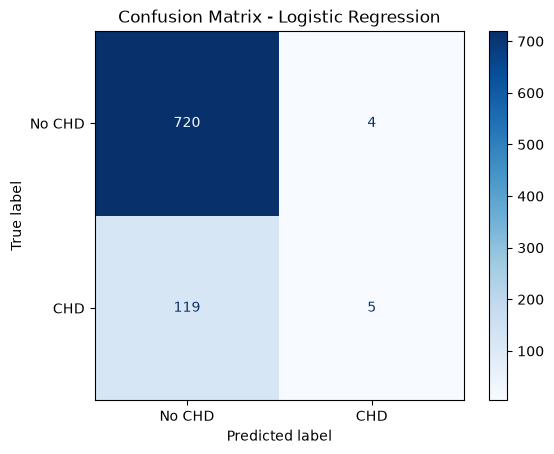

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, log_pred)

print("\nConfusion Matrix")
print(cm)



disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CHD", "CHD"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Cross Validation**

In [93]:
cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Accuracy Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:", cv_scores.mean())


Cross Validation Accuracy Scores:
[0.85495283 0.85023585 0.84316038 0.85005903 0.85123967]

Average CV Accuracy: 0.8499295515804949


In [94]:
log_train_pred = log_model.predict(X_train)

train_accuracy = accuracy_score(y_train, log_train_pred)
test_accuracy = accuracy_score(y_test, log_pred)

print("\nTraining Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

difference = train_accuracy - test_accuracy

if train_accuracy < 0.80 and test_accuracy < 0.80:
    print("\nModel Status : Underfitting")
elif difference > 0.10:
    print("\nModel Status : Overfitting")
elif difference <= 0.05:
    print("\nModel Status : Good Fit")
else:
    print("\nModel Status : Slight Overfitting")


Training Accuracy : 0.8489675516224189
Testing Accuracy  : 0.8549528301886793

Model Status : Good Fit


## **8.Save the Best Model**

In [95]:
import joblib

In [96]:
joblib.dump(best_model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [97]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## **9. Load the Best Model**

In [98]:
model = joblib.load("heart_disease_model.pkl")

In [99]:
scaler = joblib.load("scaler.pkl")

In [100]:
print(model)

Model        Logistic Regression
Accuracy                0.854953
Precision               0.555556
Recall                  0.040323
F1 Score                0.075188
Name: 0, dtype: object


## **10.Make a New Prediction**

In [102]:
# Replace these values with user input
new_data = np.array([[1, 55, 2, 1, 20, 0, 0, 1, 0, 240, 140, 90, 28.5, 75, 95]])

# Scale the input
new_data_scaled = scaler.transform(new_data)

# Predict
# Use the trained classifier object (not the summary Series)
best_classifier = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}[best_model["Model"]]

prediction = best_classifier.predict(new_data_scaled)


In [103]:
new_data

array([[  1. ,  55. ,   2. ,   1. ,  20. ,   0. ,   0. ,   1. ,   0. ,
        240. , 140. ,  90. ,  28.5,  75. ,  95. ]])

In [104]:
new_data_scaled = scaler.transform(new_data)
prediction = best_classifier.predict(new_data_scaled)

print("Predicted Patient Data :", prediction[0])

Predicted Patient Data : 1


In [106]:
if prediction[0] == 1:
    print("Prediction: Patient is Diabetic")
else:
    print("Prediction: Patient is Not Diabetic")



Prediction: Patient is Diabetic


In [112]:
probability = best_classifier.predict_proba(new_data_scaled)

print("Probability of Not Diabetic:", probability[0][0])
print("Probability of Diabetic:", probability[0][1])

Probability of Not Diabetic: 0.4299667078813231
Probability of Diabetic: 0.5700332921186769


## **Future Scope**

- Increase the dataset size to improve model robustness.
- Perform advanced hyperparameter tuning using Grid Search or Random Search.
- Apply feature selection techniques to improve prediction performance.
- Deploy the best-performing model using Streamlit, Flask, or FastAPI.
- Integrate the model with a real-time database or web application for live predictions.
- Explore ensemble and deep learning models for further performance improvement.

# **Conclusion**
 - This project successfully developed a complete Machine Learning classification pipeline, beginning with data collection and preprocessing and progressing through exploratory data analysis, feature engineering, model training, evaluation, and comparison. Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, Support Vector Machine (SVM), K-Nearest Neighbors (KNN), were implemented and evaluated using performance metrics such as Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

- The comparative analysis helped identify the best-performing model for the given dataset. The results demonstrate that proper data preprocessing, feature engineering, and model selection significantly improve prediction accuracy and overall model performance. This project also highlights the importance of evaluating multiple algorithms rather than relying on a single model.

- Overall, the project provides a practical understanding of the complete Machine Learning workflow and serves as a strong foundation for solving real-world classification problems. In the future, the model can be further improved through hyperparameter tuning, feature selection, ensemble methods, and deployment as a web application using Streamlit or Flask.

# **🎯 Completed the ML Classification Project 🚀🤖📊**